# 🎓 Sistema de Previsão de Risco Acadêmico

## Notebook 04 - Score de Risco e Outputs Gerenciais

# 1 - Introdução
Neste notebook, o modelo treinado é utilizado para gerar
probabilidades de aprovação, recuperação e reprovação.

Essas probabilidades são convertidas em um score de risco,
permitindo que a coordenação pedagógica identifique alunos
que demandam maior atenção no último bimestre.

# 2 - Ferramentas e Bibliotecas utilizadas

- Python;
- pandas, numpy: manipulação mínima e organização dos dados
- matplotlib, seaborn: visualização de gráficos
- scikit-learn: treinamento, validação cruzada e avaliação dos modelos

# 3 - Importação das Bibliotecas

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split


# 4 - Importação dos dados

In [11]:
# DataFrame processado com as features criadas
df = pd.read_csv("../data/processed/dados_academicos_processados.csv")
df.head()

,Unnamed: 0,prova_b1,prova_b2,prova_b3,trab1_b1,trab1_b2,trab1_b3,trab2_b1,trab2_b2,trab2_b3,freq_b1,freq_b2,freq_b3,idade,serie,media_nota_b1_b3,media_freq_b1_b3,slope_nota,var_nota,resultado_final
0,0,6.5,5.9,4.8,0.2,0.1,0.7,0.3,0.3,0.8,77.7,84.2,51.0,13,6,6.533333,70.966667,-0.7,0.163333,0
1,1,3.8,7.0,3.7,0.3,0.1,0.7,0.1,0.3,0.3,75.2,94.1,88.6,14,7,5.433333,85.966667,0.5,2.963333,1
2,2,5.9,6.8,5.6,0.2,0.9,0.1,0.4,0.1,0.5,59.7,60.2,58.5,11,6,6.833333,59.466667,-0.3,0.723333,0
3,3,6.0,3.8,3.6,0.4,0.2,0.9,0.3,0.7,1.0,92.9,93.7,52.2,13,6,5.633333,79.600000,-1.2,1.013333,0
4,4,5.1,3.7,7.7,0.1,0.8,0.6,0.7,0.0,0.7,83.8,53.0,82.7,13,7,6.466667,73.166667,3.1,5.303333,2


In [12]:
# DataFrame antes da criação das features
df_raw = pd.read_csv("../data/raw/dados_academicos.csv")
df_raw.head()

,id_aluno,idade,serie,prova_b1,trab1_b1,trab2_b1,freq_b1,prova_b2,trab1_b2,trab2_b2,...,trab1_b4,trab2_b4,freq_b4,nota_b1,nota_b2,nota_b3,nota_b4,nota_final,frequencia_final,resultado_final
0,1,13,6,6.5,0.2,0.3,77.7,5.9,0.1,0.3,...,0.2,0.7,77.9,7.0,6.3,6.3,4.8,6.100,72.70,Reprovado
1,2,14,7,3.8,0.3,0.1,75.2,7.0,0.1,0.3,...,0.4,0.1,52.9,4.2,7.4,4.7,4.9,5.300,77.70,Recuperação
2,3,11,6,5.9,0.2,0.4,59.7,6.8,0.9,0.1,...,0.6,0.2,84.8,6.5,7.8,6.2,4.6,6.275,65.80,Reprovado
3,4,13,6,6.0,0.4,0.3,92.9,3.8,0.2,0.7,...,0.8,0.8,52.6,6.7,4.7,5.5,5.6,5.625,72.85,Reprovado
4,5,13,7,5.1,0.1,0.7,83.8,3.7,0.8,0.0,...,0.9,0.5,90.9,5.9,4.5,9.0,9.3,7.175,77.60,Aprovado


# 5 - Treinar o modelo final

Embora a Regressão Logística tenha apresentado desempenho semelhante,
o Random Forest foi selecionado para a etapa final de geração do score
de risco por sua maior robustez, capacidade de capturar padrões não
lineares e melhor separação probabilística entre as classes.

Essas características tornam o modelo mais adequado para uso
operacional em dashboards e apoio à tomada de decisão pedagógica.


In [13]:
# Treino do modelo final

X = df.drop(columns=['resultado_final'])
y = df['resultado_final']

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X, y)


RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

# 6 - Cálculo das probabilidades por classe

In [14]:
proba = rf.predict_proba(X)

proba_df = pd.DataFrame(
    proba,
    columns=[
        'prob_reprovado',
        'prob_recuperacao',
        'prob_aprovado'
    ]
)

proba_df.head()

,prob_reprovado,prob_recuperacao,prob_aprovado
0,0.89,0.090,0.020
1,0.06,0.935,0.005
2,0.98,0.010,0.010
3,0.81,0.175,0.015
4,0.12,0.125,0.755


As probabilidades representam a confiança do modelo
em cada possível situação final do aluno.

# 7 - Construção do Score de Risco

O score de risco é baseado principalmente na probabilidade
de reprovação e recuperação, priorizando a identificação
de alunos em situação crítica.


In [15]:
# Cálculo do Score de Risco
df_scores = df.copy()

df_scores = pd.concat([df_scores, proba_df], axis=1)

df_scores['score_risco'] = (
    df_scores['prob_reprovado'] * 100 +
    df_scores['prob_recuperacao'] * 50
)



📌 Interpretação simples:

Reprovação pesa mais

Recuperação pesa médio

Aprovação não soma risco

# 7 - Classificação de Risco

In [18]:
# Função para classificação de risco
def classificar_risco(score):
    if score >= 70:
        return 'Alto Risco'
    elif score >= 40:
        return 'Risco Moderado'
    else:
        return 'Baixo Risco'

df_scores['nivel_risco'] = df_scores['score_risco'].apply(classificar_risco)

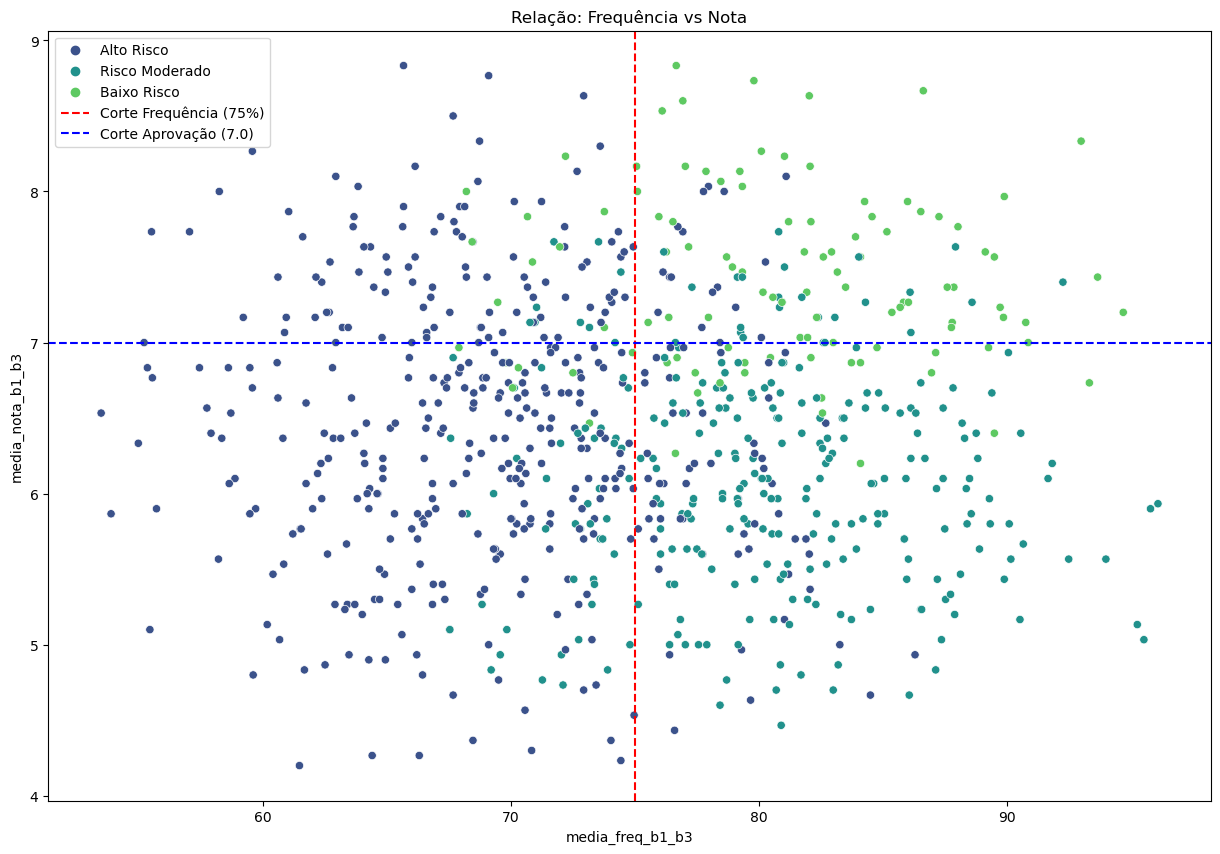

In [19]:
# Visualização da dispersão de risco

plt.figure(figsize=(15, 10))
sns.scatterplot(data=df_scores, x='media_freq_b1_b3', y='media_nota_b1_b3', hue='nivel_risco', palette='viridis')
plt.axvline(75, color='red', linestyle='--', label='Corte Frequência (75%)')
plt.axhline(7, color='blue', linestyle='--', label='Corte Aprovação (7.0)')
plt.title('Relação: Frequência vs Nota')
plt.legend()
plt.show()

In [20]:
# Criação de função para calcular as porcentagens dentro de cada nível de risco

def calcular_resumo_risco(df):
    # Criação de uma cópia para não alterar o DF original e trabalhar com as condições booleanas
    temp_df = df.copy()
    
    # Critério 1: Frequência <= 75
    temp_df['cond_freq'] = temp_df['media_freq_b1_b3'] <= 75
    
    # Critério 2: Nota <= 7.0
    temp_df['cond_nota'] = temp_df['media_nota_b1_b3'] <= 7.0
    
    # Critério 3: Ambos (Frequência <= 75 E Nota <= 7.0)
    temp_df['cond_ambos'] = temp_df['cond_freq'] & temp_df['cond_nota']
    
    # Agrupamento por nível de risco e calculo da média das colunas booleanas
    resumo = temp_df.groupby('nivel_risco')[['cond_freq', 'cond_nota', 'cond_ambos']].mean() * 100
    
    # Renomeando as colunas 
    resumo.columns = [
        '% Frequência <= 75', 
        '% Notas <= 7', 
        '% Freq <= 75 e Nota <= 7'
    ]
    
    # Reordenar as linhas para Alto -> Moderado -> Baixo
    ordem = ['Alto Risco', 'Risco Moderado', 'Baixo Risco']
    resumo = resumo.reindex(ordem)
    
    return resumo

# Execução
df_resumo = calcular_resumo_risco(df_scores)
df_resumo


    

,% Frequência <= 75,% Notas <= 7,% Freq <= 75 e Nota <= 7
nivel_risco,,,
Alto Risco,82.608696,72.946860,59.420290
Risco Moderado,19.285714,89.285714,16.428571
Baixo Risco,15.094340,29.245283,6.603774


Como esperado a maioria dos alunos que se encontra em Alto Risco de reprovação possui uma frequência abaixo do mínimio até o fim do 
terceiro bimestre. E quase 60% destes alunos exibem dois problemas, baixa frequência e notas baixas. 
A frequência continua indicando que é a variável mais importante para a aprovação já que constitui uma regra da escola.

# 8 - Distribuição dos níveis de Risco

Essa segmentação permite ações pedagógicas direcionadas
e priorização de recursos educacionais.


In [22]:
df_scores['nivel_risco'].value_counts(normalize=True)

Alto Risco        0.5175
Risco Moderado    0.3500
Baixo Risco       0.1325
Name: nivel_risco, dtype: float64

Este seria um resultado preocupante para uma escola, pois mais de 50% dos alunos se encontram em alto risco de reprovação ao final do terceiro bimestre. Neste caso, é muito provável que para muitos destes alunos não seja possível empenhar alguma ação que evite sua reprovação. 

# 9 - Dataset final para o dashboard

In [24]:
# Supondo que df1 seja o primeiro (com b4 e id_aluno) e df2 o segundo (com scores)
# Selecionamos do df2 apenas o id_aluno e as colunas que NÃO existem no df1 para evitar duplicidade
colunas_preditivas = [
    'id_aluno', 'media_nota_b1_b3', 'media_freq_b1_b3', 
    'slope_nota', 'var_nota', 'prob_reprovado', 
    'prob_recuperacao', 'prob_aprovado', 'score_risco', 'nivel_risco'
]

# Nota: Se o df2 não tiver 'id_aluno', mas estiver na mesma ordem, 
# adicione o ID antes do merge: df2['id_aluno'] = df1['id_aluno']

df_scores['id_aluno'] = df_raw['id_aluno']

df_final = pd.merge(
    df_raw, 
    df_scores[colunas_preditivas], 
    on='id_aluno', 
    how='inner'
)


# 2. Exportação para CSV (configurada para o Power BI)
# Usamos index=False para não criar uma coluna de números sem nome no BI
# Usamos encoding='utf-8-sig' para garantir que acentos apareçam corretamente no Windows/Power BI
df_final.to_csv(
    "../data/processed/dados_dashboard_final.csv", 
    index=False, 
    encoding='utf-8-sig', 
    sep=';'
)

print("Arquivo exportado com sucesso!")


Arquivo exportado com sucesso!


# 10 - Conclusão

A construção do score de risco acadêmico permitiu segmentar os alunos em níveis
de risco com clara diferenciação de perfil. Observou-se que mais da metade dos
alunos classificados como Alto Risco apresentavam problemas de frequência até
o terceiro bimestre, reforçando o papel da assiduidade como critério determinante
para a aprovação.

Adicionalmente, cerca de 60% desses alunos acumulavam simultaneamente baixa
frequência e notas insuficientes, indicando a necessidade de intervenções
pedagógicas combinadas. Já os grupos de Risco Moderado e Baixo Risco apresentaram
perfis distintos, sugerindo estratégias de acompanhamento diferenciadas.

Esses resultados demonstram que o score de risco não apenas antecipa a situação
final do aluno, mas também fornece subsídios práticos para a priorização de ações
pedagógicas de forma orientada por dados.



# 11 - Próximos passos

Como continuidade deste projeto, os dados consolidados com o score de risco
podem ser utilizados para:

- Construção de dashboards interativos para acompanhamento pedagógico;
- Monitoramento da evolução dos alunos ao longo dos bimestres;
- Avaliação do impacto de intervenções pedagógicas aplicadas após o 3º bimestre;
- Integração futura com dados reais, ampliando a capacidade preditiva e analítica
  do modelo.

Esses próximos passos permitem transformar a modelagem preditiva em uma
ferramenta operacional contínua no ambiente escolar.
